**Сначала переключитесь на графический процессор!**

# 6. Практическое занятие. Свёрточные нейронные сети (CNN)

**Цель работы:** Познакомиться с архитектурой CNN, научиться строить и обучать свёрточные сети для классификации изображений, визуализировать карты активации и экспериментировать с архитектурными решениями.

В этой практике мы будем использовать датасет CIFAR-10 (32x32 цветных изображения, 10 классов).

## 0. Импорты и подготовка данных

Импортируем необходимые библиотеки и загружаем CIFAR-10.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



Using device: cuda


In [2]:
# Загрузка данных CIFAR-10
# Для ускорения возьмём подвыборку (первые 10000 обучающих, 2000 тестовых)
# Но можно и полный датасет, если есть время.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Для экспериментов возьмём подвыборку (ускорит обучение)
num_train = 10000
num_val = 2000
indices = torch.randperm(len(train_full))
train_indices = indices[:num_train]
val_indices = indices[num_train:num_train+num_val]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(train_full, val_indices)
test_dataset = test_full

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Train samples: 10000
Val samples: 2000
Test samples: 10000


In [3]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f'Train size: {len(train_dataset)}, Test size: {len(test_dataset)}')

Train size: 10000, Test size: 10000


## 1. Построение базовой CNN (10 мин)

Определим класс `SimpleCNN` с двумя свёрточными слоями, пулингом и полносвязными слоями.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # 32x32 -> 32x32
        self.pool = nn.MaxPool2d(2)                               # 32x32 -> 16x16
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 16x16 -> 16x16
        # После второго пулинга: 64 канала * 8 * 8
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # x - входное изображение.
        x = self.pool(F.relu(self.conv1(x)))
        # теперь x - 32 карты признаков размером 16x16
        x = self.pool(F.relu(self.conv2(x)))
        # теперь x - 64 карты признаков размером 8x8

        # растягиваем тензор 64х8х8 в один большой вектор.
        x = x.view(x.size(0), -1)  # flatten

        x = self.dropout(F.relu(self.fc1(x)))
        # теперь х - вектор из 256 результатов активации нейронов
        x = self.fc2(x)
        # теперь х - вектор из 10 чисел, имеющих значения (-inf; inf).
        # Т.к. ниже написан выбор кросс-энтропии в качестве функции потерь
        # для многоклассовой классификации
        # criterion = nn.CrossEntropyLoss()
        # то к х после завершения данного метода
        # ещё дополнительно применится функция softmaх,
        # которая отмасштабирует значения х до отрезка [0; 1]
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Посчитаем количество параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Количество обучаемых параметров: {count_parameters(model)}')

Количество обучаемых параметров: 1070794


## 2. Обучение и базовая оценка

Напишем функцию для одной эпохи обучения и оценки. Обучим модель на 5 эпохах и сохраним историю потерь.

Epoch 1/5, Train Loss: 1.8079, Val Loss: 1.4583, Val Acc: 0.4755
Epoch 2/5, Train Loss: 1.4201, Val Loss: 1.3210, Val Acc: 0.5250
Epoch 3/5, Train Loss: 1.2514, Val Loss: 1.2025, Val Acc: 0.5707
Epoch 4/5, Train Loss: 1.1213, Val Loss: 1.1497, Val Acc: 0.5903
Epoch 5/5, Train Loss: 1.0218, Val Loss: 1.1038, Val Acc: 0.6089

Финальная точность на тесте: 0.6089
Сравнение с MLP: MLP давал точность около 0.5, наша CNN показывает значительное улучшение.


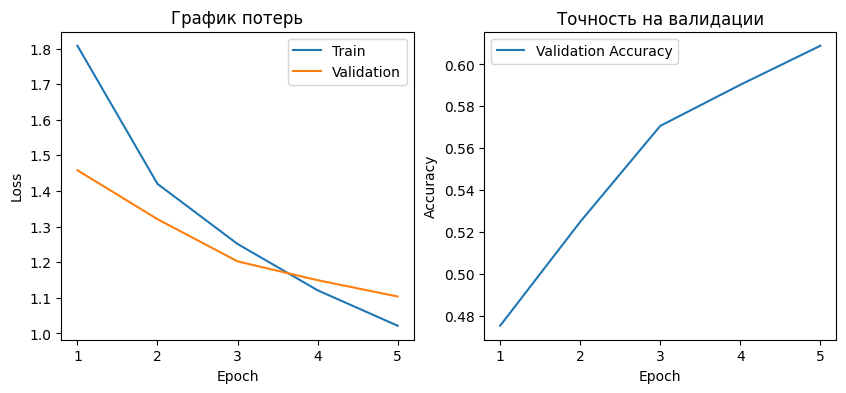

In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            loss = criterion(outputs, labels.to(device))
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()
    return running_loss / len(loader.dataset), correct / total

num_epochs = 5
train_losses = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

print(f'\nФинальная точность на тесте: {val_accs[-1]:.4f}')

# Сравнение с MLP из занятия 5 (ожидаем ~0.5)
print('Сравнение с MLP: MLP давал точность около 0.5, наша CNN показывает значительное улучшение.')

# Построим графики потерь
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('График потерь')

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Точность на валидации')
plt.show()

## 3. Визуализация карт активации

Посмотрим, что именно выучил первый свёрточный слой. Для этого выберем несколько тестовых изображений и выведем карты активации (первые несколько каналов) после первого свёрточного слоя (до пулинга).

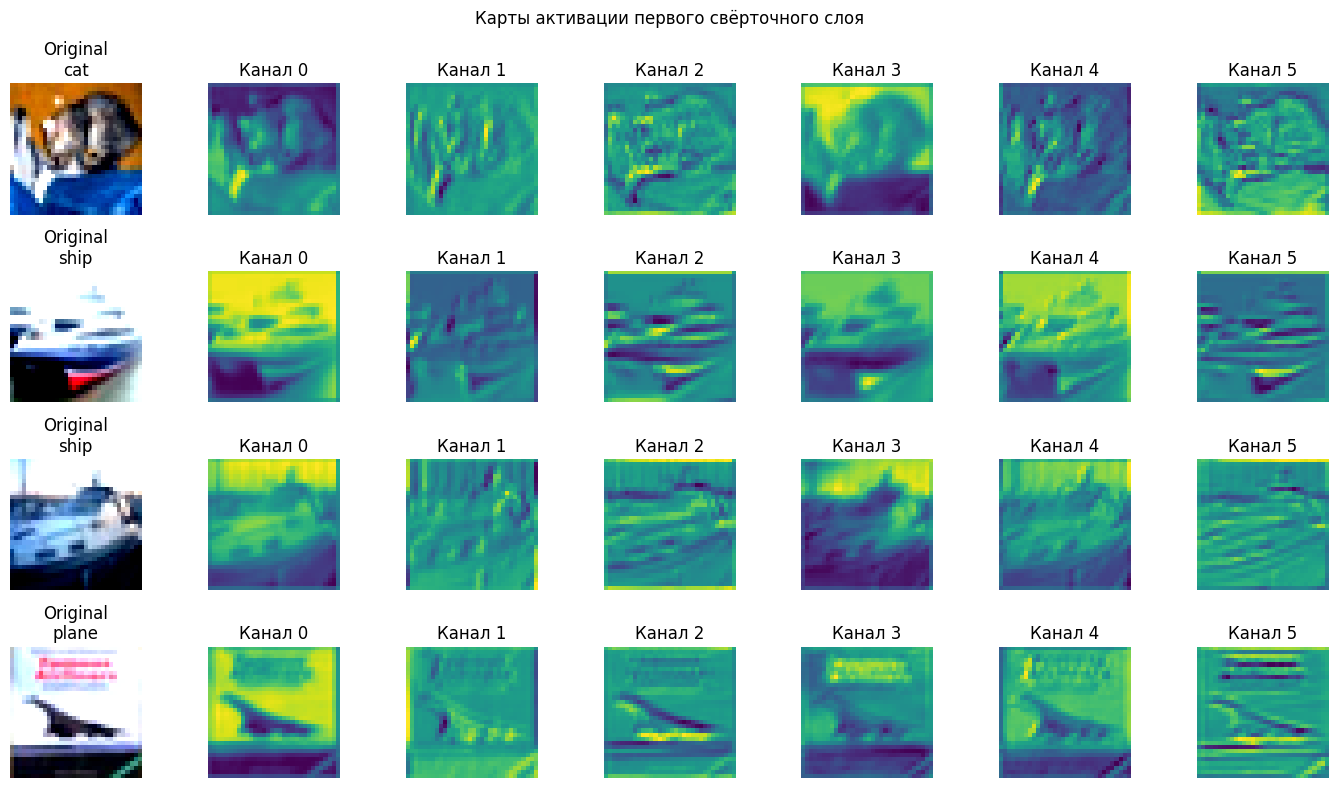

In [6]:
# Функция для получения активаций через forward hook
activations = {}
def hook_fn(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Регистрируем хук на conv1
hook = model.conv1.register_forward_hook(hook_fn('conv1'))

# Берём несколько тестовых изображений
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images[:4]  # возьмём 4 картинки

# Прогоняем через сеть (без градиентов)
with torch.no_grad():
    outputs = model(images.to(device))

# Получаем активации
acts = activations['conv1']  # (4, 32, 32, 32)

# Визуализируем исходные изображения и карты активаций (первые 6 каналов)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
for i in range(4):
    # Исходное изображение (восстанавливаем из нормализации)
    img = images[i].cpu().numpy().transpose(1,2,0)
    img = img * 0.5 + 0.5  # обратная нормализация
    axes[i, 0].imshow(np.clip(img, 0, 1))
    axes[i, 0].set_title(f'Original\n{classes[labels[i]]}')
    axes[i, 0].axis('off')

    # 6 случайных каналов
    for j in range(6):
        channel_idx = j  # можно взять первые 6, но для разнообразия используем случайные
        ax = axes[i, j+1]
        ax.imshow(acts[i, channel_idx].cpu(), cmap='viridis')
        ax.set_title(f'Канал {channel_idx}')
        ax.axis('off')

plt.suptitle('Карты активации первого свёрточного слоя')
plt.tight_layout()
plt.show()

hook.remove()


Задание: Опишите, какие признаки активируют разные каналы (контуры, текстуры, цвета). Заметно ли, что карты примерно соответствуют очертаниям объектов? (Из-за маленького размера 32x32 и нормализации это может быть неочевидно, но попытайтесь увидеть границы.)

### Канал 0 отделяет белые (и близкие к белому) цвета от черного (и близких к черному) цвет на картинке. На канале 2 заметно, как модель выделяет горизонтальные и вертикальные линии в изображении. Другие каналы выделяют границы объектов и показывают некую глубину картинки.

## 4. Эксперименты с архитектурой

Теперь вы самостоятельно модифицируете архитектуру и сравниваете результаты. Выберите **2-3** варианта из предложенных ниже, реализуйте соответствующие модели, обучите их на **3-5 эпохах** (для экономии времени) и запишите точность и количество параметров.

**Варианты модификаций:**
1. Увеличить число каналов: `conv1(3, 64)`, `conv2(64, 128)`.
2. Добавить третий свёрточный блок (Conv+Pool).
3. Заменить MaxPool на `stride=2` в свёртке (убрать явный пулинг).
4. Изменить размер ядра на 5 (учесть изменение padding для сохранения размера).
5. Добавить `BatchNorm2d` после каждой свёртки.
6. Заменить `Linear` на Global Average Pooling: `x = torch.mean(x, [2,3])` и затем один линейный слой.

Для каждой модели заполняйте таблицу (можно просто выводить на печать).

In [14]:
# Пример реализации одной из модификаций (увеличение числа каналов)
class WiderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class WiderCNN_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(256 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
    
class WiderCNN_3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, stride=2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class WiderCNN_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class WiderCNN_5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(128)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.batch_norm1(self.pool(F.relu(self.conv1(x))))
        x = self.batch_norm2(self.pool(F.relu(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


# Здесь студенты должны написать код для обучения и оценки каждой модификации
# Совет: создайте список моделей и для каждой проводите обучение.

# Пример вывода таблицы (можно оформить как pandas DataFrame, но для простоты просто print)
#print("Модель\tПараметры\tТочность")
#print("-" * 30)
# Для каждой модели выведите строку

criterion = nn.CrossEntropyLoss().to(device)
models = [
    (WiderCNN().to(device=device), 'default'), 
    (WiderCNN_1().to(device=device), '#1'), 
    (WiderCNN_3().to(device=device), '#3'), 
    (WiderCNN_4().to(device=device), '#4'), 
    (WiderCNN_5().to(device=device), '#5')
]

import pandas as pd
result = pd.DataFrame()

for model, name in models:
    #print(f'Model: {name}')
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion.to(device=device))
        val_loss, val_acc = evaluate(model, test_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        #print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    result = pd.concat([result, pd.DataFrame({
        'model': [name],
        'params': [model],
        'test_acc': [val_acc]
    })])
result

,model,params,test_acc
0,default,"WiderCNN(\n (conv1): Conv2d(3, 64, kernel_siz...",0.6041
0,#1,"WiderCNN_1(\n (conv1): Conv2d(3, 128, kernel_...",0.5782
0,#3,"WiderCNN_3(\n (conv1): Conv2d(3, 64, kernel_s...",0.6055
0,#4,"WiderCNN_4(\n (conv1): Conv2d(3, 64, kernel_s...",0.5872
0,#5,"WiderCNN_5(\n (conv1): Conv2d(3, 64, kernel_s...",0.6432


## 5. Depthwise Separable Convolution

Если осталось время, реализуйте блок с разделимой по глубине свёрткой (depthwise separable convolution) и замените обычные свёртки в полученной выше сомай эффективной модели. Сравните число параметров и точность.

In [15]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                    padding=kernel_size//2, groups=in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x):
        return self.pointwise(F.relu(self.depthwise(x)))

class DepthwiseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(3, 32, 3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = DepthwiseSeparableConv(32, 64, 3)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model_ds = DepthwiseCNN().to(device)
print(f'Параметры DepthwiseCNN: {count_parameters(model_ds)}')
print(f'Параметры базовой CNN: {count_parameters(SimpleCNN())}')
# Обучите модель (можно на 3 эпохах) и сравните точность

Параметры DepthwiseCNN: 1053992
Параметры базовой CNN: 1070794


**Задача**: добавить цикл обучения к этому варианту свёртки и сравнить полученную точность.

In [17]:
criterion = nn.CrossEntropyLoss().to(device)
#print(f'Model: {name}')
optimizer = optim.Adam(model_ds.parameters(), lr=0.001)
for epoch in range(num_epochs):
    train_loss = train_epoch(model_ds, train_loader, optimizer, criterion.to(device=device))
    val_loss, val_acc = evaluate(model_ds, test_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch 1/5, Train Loss: 2.1141, Val Loss: 1.8486, Val Acc: 0.3462
Epoch 2/5, Train Loss: 1.8131, Val Loss: 1.6541, Val Acc: 0.4076
Epoch 3/5, Train Loss: 1.6748, Val Loss: 1.5347, Val Acc: 0.4396
Epoch 4/5, Train Loss: 1.5836, Val Loss: 1.4895, Val Acc: 0.4605
Epoch 5/5, Train Loss: 1.5227, Val Loss: 1.4463, Val Acc: 0.4822


### Качество этой модели хуже: у неё на 5 эпохе точность 48.22%, в то время как у WiderCNN_5 - 64.32%.

## 6. Классификация изображений

**Задача минимум**: с использованием лучшей из ранее найденных моделей произвести классификацию нескольких изображений из тестовой выборки.<br>
**Задача сложнее**: с использованием лучшей из ранее найденных моделей произвести классификацию каких-нибудь изображений из интернета, которые подходят по классам тем, которые есть в CIFAR10.
Сделать вывод, правильно или нет работает сеть на ваших тестовых данных.

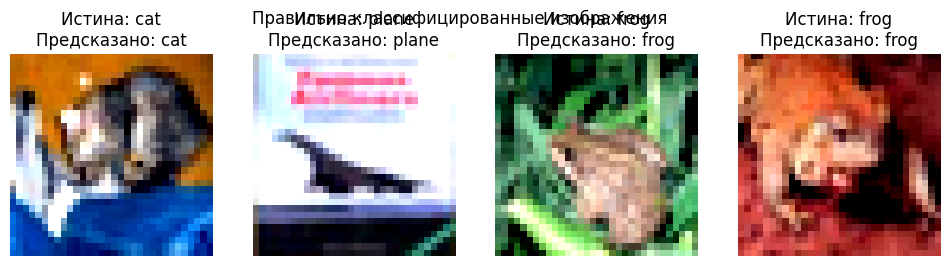

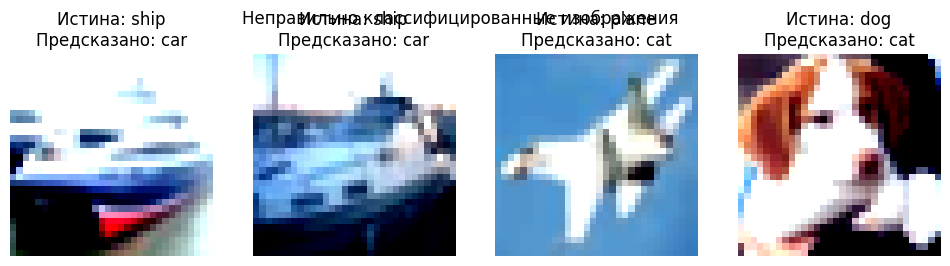

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Переводим модель в режим оценки
model.eval()

# Получаем один батч из тестового набора
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Делаем предсказания
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# Преобразуем тензоры в numpy для визуализации
images = images.numpy()
labels = labels.numpy()
predicted = predicted.cpu().numpy()

# Найдём индексы правильно и неправильно классифицированных
correct_indices = np.where(predicted == labels)[0]
incorrect_indices = np.where(predicted != labels)[0]

# Выберем по 4 примера (если есть)
num_to_show = 4
correct_to_show = correct_indices[:num_to_show] if len(correct_indices) >= num_to_show else correct_indices
incorrect_to_show = incorrect_indices[:num_to_show] if len(incorrect_indices) >= num_to_show else incorrect_indices

# Функция отображения
def show_examples(indices, title):
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices), i+1)
        # Восстанавливаем изображение из нормализации
        img = images[idx].transpose(1, 2, 0)
        img = img * 0.5 + 0.5  # обратная нормализация
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f'Истина: {classes[labels[idx]]}\nПредсказано: {classes[predicted[idx]]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Показываем правильно классифицированные
if len(correct_to_show) > 0:
    show_examples(correct_to_show, 'Правильно классифицированные изображения')
else:
    print("Нет правильно классифицированных примеров в этом батче.")

# Показываем неправильно классифицированные
if len(incorrect_to_show) > 0:
    show_examples(incorrect_to_show, 'Неправильно классифицированные изображения')
else:
    print("Нет неправильно классифицированных примеров в этом батче.")

## 6. Выводы

В этой ячейке напишите краткие выводы по работе:
- Почему CNN работает лучше MLP на CIFAR-10?
- Какие модификации архитектуры дали наибольший прирост качества и почему?
- Как изменилось количество параметров при различных изменениях?
- Что показала визуализация карт активации?

Используйте термины: рецептивное поле, локальность, разделение весов, регуляризация (dropout, batch norm), ёмкость модели, переобучение.

1. CNN работает лучше MLP на CIFAR-10 из-за того, что свёрточные слои обрабатывают небольшие области изображения (рецептивное поле 3×3), что позволяет выделять локальные признаки. Также из-за нескольких слоев модели происходит иерархиеское разделение, из-за чего первые слои учат простые паттерны, последующие — более сложные. При этом MLP игнорирует пространственную структуру, то есть она рассматривет отдельные пиксели как независимые признаки.
2. Заметный прирост в качестве показало добавление BatchNorm2d на каждом слое. Это произошло потому, что он добавил обучению стабильности, выступая в качестве регуляризатора.
3. При увеличении каналов количество параметров резко возрастало.
4. Первые слои нейросети выучиывают общие контуры, в то время как последующие учат более конкретные отличия. Карты активации в целом схожи на исходные изображения.

Новые навыки/умения/знания.
Пожелания по содержимому лекции ипрактики.